🔹 Step 1: Environment Setup

In [137]:
# Install required libraries (run once)
# pip install pandas numpy matplotlib scikit-learn tensorflow

In [138]:
!python --version

Python 3.12.12


🔹 Step 2: Import Libraries

In [139]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

🔹 Step 3: Load & Inspect Dataset

In [140]:
df = pd.read_csv("Job_3_Resource_sentiment.csv")
print(df.columns)

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


In [141]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [142]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [143]:
df.rename(columns={'Positive': 'sentiment'}, inplace=True)
df.rename(columns={'im getting on borderlands and i will murder you all ,': 'text'}, inplace=True)

In [144]:
df.columns

Index(['2401', 'Borderlands', 'sentiment', 'text'], dtype='object')

In [145]:
df.sample(5)

,2401,Borderlands,sentiment,text
32800,6428,Fortnite,Positive,had the best night with a boyz
56113,11231,TomClancysRainbowSix,Irrelevant,My friends from RB6.
30359,7218,LeagueOfLegends,Positive,AMAZING SYNERGY MOMENTS (Wombo Combo League of...
68976,3813,Cyberpunk2077,Positive,Keanuuuu and Cyberpunk is the best Union I ask...
25468,4771,Google,Irrelevant,@fire_google million in


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   2401         74681 non-null  int64 
 1   Borderlands  74681 non-null  object
 2   sentiment    74681 non-null  object
 3   text         73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [147]:
df = df[['text', 'sentiment']]

In [148]:
df.sample(5)

,text,sentiment
13899,The @NBA2K finally you showed in me love and g...,Positive
55982,Fuck YouTube fuck twitch I cannot technically ...,Neutral
35951,So @Microsoft say get a new PC. Even though I ...,Negative
29151,6 It was a good feeling being home back in Kin...,Positive
25380,The hardest thing about being blind on social ...,Irrelevant


In [149]:
df

,text,sentiment
0,I am coming to the borders and I will kill you...,Positive
1,im getting on borderlands and i will kill you ...,Positive
2,im coming on borderlands and i will murder you...,Positive
3,im getting on borderlands 2 and i will murder ...,Positive
4,im getting into borderlands and i can murder y...,Positive
...,...,...
74676,Just realized that the Windows partition of my...,Positive
74677,Just realized that my Mac window partition is ...,Positive
74678,Just realized the windows partition of my Mac ...,Positive
74679,Just realized between the windows partition of...,Positive


In [150]:
df.shape

(74681, 2)

In [151]:
df.isnull().sum()

,0
text,686
sentiment,0


In [152]:
print(df['sentiment'].value_counts())

sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [153]:
df.duplicated().sum()

np.int64(4909)

🔹 Step 4: Data Cleaning

In [154]:
df.dropna(inplace=True)

In [155]:
df.isnull().sum()

,0
text,0
sentiment,0


In [156]:
df['text'] = df['text'].astype(str)

In [157]:
df['text']

,text
0,I am coming to the borders and I will kill you...
1,im getting on borderlands and i will kill you ...
2,im coming on borderlands and i will murder you...
3,im getting on borderlands 2 and i will murder ...
4,im getting into borderlands and i can murder y...
...,...
74676,Just realized that the Windows partition of my...
74677,Just realized that my Mac window partition is ...
74678,Just realized the windows partition of my Mac ...
74679,Just realized between the windows partition of...


In [158]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

In [159]:
df['text']

,text
0,i am coming to the borders and i will kill you...
1,im getting on borderlands and i will kill you all
2,im coming on borderlands and i will murder you...
3,im getting on borderlands and i will murder y...
4,im getting into borderlands and i can murder y...
...,...
74676,just realized that the windows partition of my...
74677,just realized that my mac window partition is ...
74678,just realized the windows partition of my mac ...
74679,just realized between the windows partition of...


🔹 Step 5: Encode Target Labels

In [160]:
encoder = LabelEncoder()
df['sentiment_encoded'] = encoder.fit_transform(df['sentiment'])

print("Label mapping:")
for i, c in enumerate(encoder.classes_):
    print(i, "->", c)

Label mapping:
0 -> Irrelevant
1 -> Negative
2 -> Neutral
3 -> Positive


In [161]:
encoder.classes_

array(['Irrelevant', 'Negative', 'Neutral', 'Positive'], dtype=object)

In [162]:
df.sample(10)

,text,sentiment,sentiment_encoded
41382,ea prohibits dxvk on the battlefield v forumsl...,Irrelevant,0
72025,it was close i almost ran over lou i still don...,Neutral,2
21416,cs go with weird people twitchtvdoubletrouble,Neutral,2
11320,lookunk your sexy sparkly in art,Positive,3
15004,server is in pls fix dota,Negative,1
50438,fifa soars to double top of the charts this s...,Positive,3
14051,geek fam win one esports dota sea league gee...,Neutral,2
25044,googlechrome every time i open google keep it ...,Negative,1
36998,microsoft confirms internet explorer virus has...,Neutral,2
46075,breaking major outages and cell phone problems...,Negative,1


🔹 Step 6: Text Tokenization & Padding

In [163]:
max_words = 20000
max_length = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df['text']),
    maxlen=max_length,
    padding='post'
)

y = df['sentiment_encoded'].values

In [164]:
tokenizer

In [165]:
df

,text,sentiment,sentiment_encoded
0,i am coming to the borders and i will kill you...,Positive,3
1,im getting on borderlands and i will kill you all,Positive,3
2,im coming on borderlands and i will murder you...,Positive,3
3,im getting on borderlands and i will murder y...,Positive,3
4,im getting into borderlands and i can murder y...,Positive,3
...,...,...,...
74676,just realized that the windows partition of my...,Positive,3
74677,just realized that my mac window partition is ...,Positive,3
74678,just realized the windows partition of my mac ...,Positive,3
74679,just realized between the windows partition of...,Positive,3


In [166]:
X.shape

(73995, 100)

In [167]:
X.dtype

dtype('int32')

In [168]:
y.shape

(73995,)

In [169]:
y.dtype

dtype('int64')

In [170]:
X.ndim

2

In [171]:
y.ndim

1

In [172]:
X.nbytes

29598000

In [173]:
y.nbytes

591960

In [174]:
X

array([[   3,  101,  377, ...,    0,    0,    0],
       [  31,  158,   14, ...,    0,    0,    0],
       [  31,  377,   14, ...,    0,    0,    0],
       ...,
       [  22, 1837,    2, ...,    0,    0,    0],
       [  22, 1837,  693, ...,    0,    0,    0],
       [  22,   32,    2, ...,    0,    0,    0]], dtype=int32)

In [175]:
y

array([3, 3, 3, ..., 3, 3, 3])

🔹 Step 7: Train / Validation / Test Split (MANDATORY)

In [176]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)



Train: (51796, 100)
Validation: (11099, 100)
Test: (11100, 100)


Handle Bias (Class Weight)

In [177]:
print(np.bincount(y_train))

[ 9012 15650 12676 14458]


In [178]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.4368619618286729), 1: np.float64(0.8274121405750798), 2: np.float64(1.0215367623856106), 3: np.float64(0.8956287176649605)}


In [179]:
print(np.bincount(y_train))

[ 9012 15650 12676 14458]


🔹 Step 8: Build Deep Learning Model (LSTM)

In [180]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(max_words, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,332 (10.14 MB)

 Trainable params: 2,659,332 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

🔹 Step 9: Compile Model

In [181]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

🔹 Step 10: Train Model

In [182]:
early = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early],
    class_weight=class_weights_dict
)

Epoch 1/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.6404 - loss: 0.8999 - val_accuracy: 0.7689 - val_loss: 0.6289
Epoch 2/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - accuracy: 0.8318 - loss: 0.4598 - val_accuracy: 0.8237 - val_loss: 0.4774
Epoch 3/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8836 - loss: 0.3181 - val_accuracy: 0.8378 - val_loss: 0.4508
Epoch 4/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9073 - loss: 0.2472 - val_accuracy: 0.8513 - val_loss: 0.4287
Epoch 5/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9229 - loss: 0.2062 - val_accuracy: 0.8600 - val_loss: 0.4300
Epoch 6/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9331 - loss: 0.1731 - val_accuracy: 0.8555 - val_loss: 0.4865
Epoch 7/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9402 - loss: 0.1532 - val_accuracy: 0.8688 - val_loss: 0.4631


🔹 Step 11: Visualize Performance

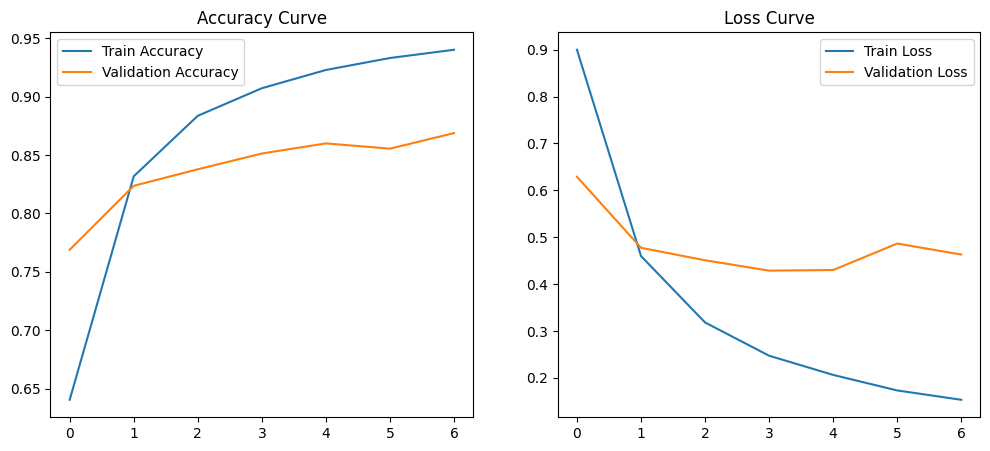

In [183]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()

🔹 Step 12: Detect Overfitting / Underfitting

In [184]:
if history.history['accuracy'][-1] > history.history['val_accuracy'][-1]:
    print("⚠️ Possible Overfitting detected")
else:
    print("✅ Model is generalizing well")

⚠️ Possible Overfitting detected


🔹 Step 13: Model Evaluation

In [185]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

347/347 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Accuracy: 0.8488288288288288
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1932
           1       0.90      0.84      0.87      3354
           2       0.85      0.83      0.84      2716
           3       0.81      0.88      0.85      3098

    accuracy                           0.85     11100
   macro avg       0.85      0.85      0.85     11100
weighted avg       0.85      0.85      0.85     11100

